# Intrusion Detection System

#### CSM423 - Machine Learning Project: Intrusion Detection System (IDS).

This project constructs an IDS with supervision where network connections are categorized as normal or anomaly based on a labeled network traffic dataset. The pipeline includes the data loading, preprocessing, class balancing, EDA, training of the model using a variety of standard classifiers, evaluation of the models, and deployment of the most successful one.


### Problem statement & solution

Issue: Network traffic is composed of normal and malicious connections. The real-world data is skewed and extremely noisy, hence it is difficult to detect intrusions in a reliable manner.
Traditional rule-based systems struggle with new or unexpected attacks. 
##### Goal: Create a machine learning model that correctly classifies network traffic as normal or anomalous.

Solution: I pre-processed the Train and Test files, encoded categorical features, standardized numerical features, balanced the classes with the help of the SMOTE, carried out EDA to see patterns, trained several classifiers (Logistic Regression, Decision Tree, Random Forest, SVM, KNN), evaluated their performance on precision/recall/F1 and confusion matrices, selected the model with the highest recall, re-trained it on full training data and saved the final model and preprocessing objects to deploy.

### Loading libraries

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib


pandas / numpy: loading and cleaning of data and numeric operations.

matplotlib / seaborn: data analysis, visualizing.

scikit-learn: encoding, scaling, model implementations, metrics and pipeline helpers.

imbalanced-learn (SMOTE): synthetic oversampling to manage the imbalance in classes.

joblib / pickle: save and load trained model and preprocessing objects (scaler, encoders).

### Uploading data files

In [2]:
train_df = pd.read_csv("Train_data.csv")
test_df  = pd.read_csv("Test_data.csv")

Train_data.csv: labeled training data applied in the estimation of preprocessing, balancing, and training models.

Test_data.csv: held-out data used to make final evaluation / predictions.

In [3]:
train_df.shape

(25192, 42)

In [4]:
test_df.shape

(22544, 41)

In [5]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [6]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00
1,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71


In [7]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [8]:
label_col = train_df.columns[-1]
print("Label Column =", label_col)

Label Column = class


Label column: the final column in the file (values: normal, anomaly) - as y.
(Change your filenames in the code in case you have different filenames.)


### Data Preprocessing

In [9]:
# separating X and y
X_train = train_df.drop(label_col, axis=1)
y_train = train_df[label_col]

In [10]:
# identifying categorical & numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns

In [11]:
print("Categorical :", list(categorical_cols))
print("Numerical   :", list(numerical_cols))

Categorical : ['protocol_type', 'service', 'flag']
Numerical   : ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [34]:
# Label encoding 
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on train data
    X_train[col] = X_train[col].astype(str)
    le.fit(X_train[col])

    # Save encoder
    encoders[col] = le

    # Transform train
    X_train[col] = le.transform(X_train[col])

    # Handle unknown categories in test
    test_df[col] = test_df[col].astype(str)
    test_df[col] = test_df[col].apply(lambda x: x if x in le.classes_ else "unknown")

    # Add "unknown" to encoder if needed
    if "unknown" not in le.classes_:
        le.classes_ = np.append(le.classes_, "unknown")

    # Transform test
    test_df[col] = le.transform(test_df[col])

In [13]:
# Scaling numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

### Handle Class Imbalance (SMOTE)

In [14]:
from imblearn.over_sampling import SMOTE

print("\nBefore SMOTE:", y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:", y_train_bal.value_counts())


Before SMOTE: class
normal     13449
anomaly    11743
Name: count, dtype: int64

After SMOTE: class
normal     13449
anomaly    13449
Name: count, dtype: int64


Why: There are usually a lot more records in intrusion datasets than attack records. Data imbalance training usually causes models to choose the majority and overlook attacks.

My action: Synthetic samples of the minority class in the feature space were generated using SMOTE (Synthetic Minority Over-sampling Technique), generating a balanced training set.

Why SMOTE: it will generate new (plausible) minority examples by i-and-ii interpolating between existing minority points, which, in many cases, allow models to better learn how to understand where to make decisions than just duplicate.
Caveats: synthetic samples may bring about noise when features are not well-scaled or categorical features are not well-encoded. Always test on untouched testing data.


### EDA - Data Visualization 

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Class Distribution - After vs Before SMOTE

Class Distribution (Before SMOTE)
Description: Bar plot of the number of normal and anomaly in original training data.
##### Analysis: 
Class imbalance (one more class) is depicted in the plot. This encourages balancing (SMOTE) since an unbalanced training sample favours models with the majority class.

Class Distribution (After SMOTE)
Description: Bar graph with counts on the usage of SMOTE.
##### Analysis: 
The classes are equalized now (equal number). This assists the model in the study of the two classes equally and generally boosts recall of the minority (attack) class.

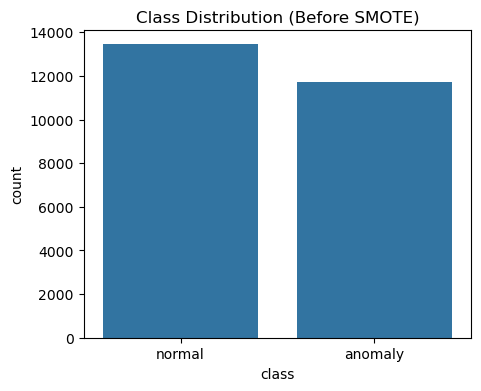

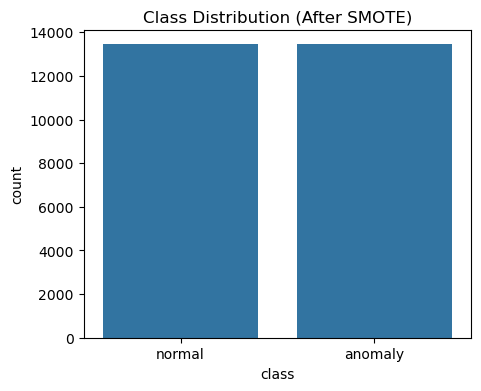

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Class Distribution (Before SMOTE)")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x=y_train_bal)
plt.title("Class Distribution (After SMOTE)")
plt.show()


#### Correlation Heatmap (categorical features)

The figure below is a heatmap of Pearson correlations among numerical features.
##### Analysis: 
Highly correlated blocks are redundant features (might do dimensionality reduction, or drop one member of a highly correlated pair). Weak/near-zero correlations imply features that can contribute to independent predictive signal.

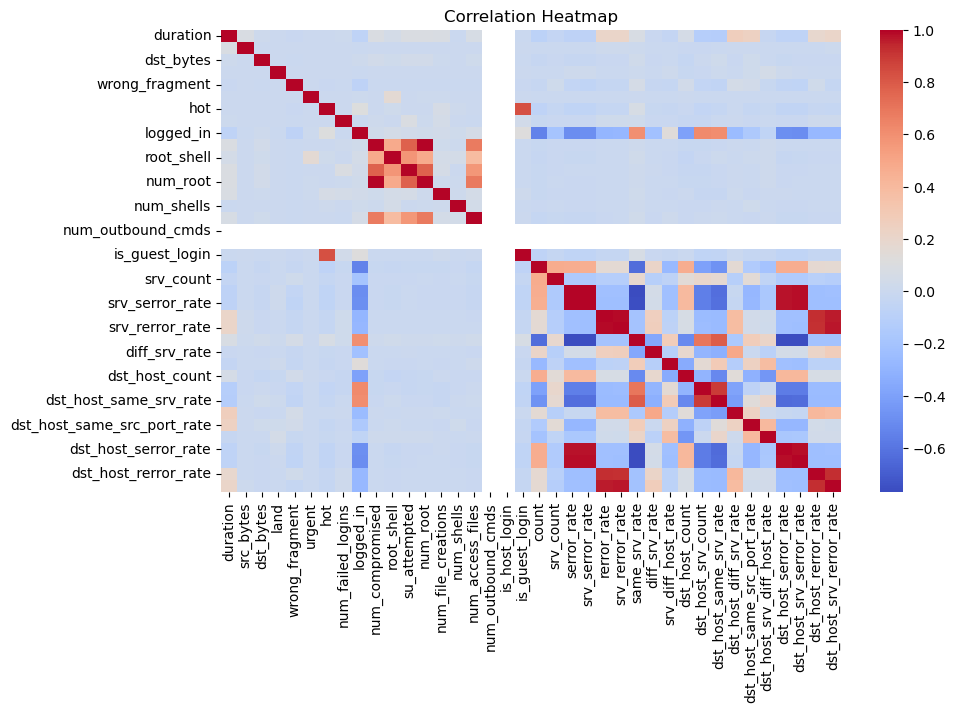

In [17]:
# Numerical correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(X_train[numerical_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


#### Type of Distribution Protocol Type Distribution (bar plot)

Description: Countplot of protocol-type (e.g., tcp, udp, icmp).
##### Analysis:
tcp is the most dominant traffic. Provided that certain protocols are highly associated with aberrant behavior, models could take that as a predictive indicator - look at protocol-specific attack behavior and beware of protocol imbalance.

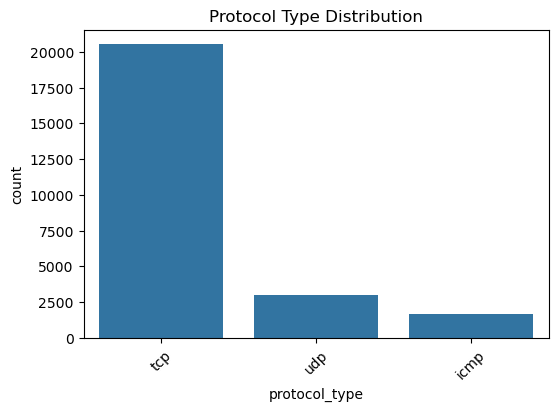

In [27]:
if "protocol_type" in categorical_cols: 
    plt.figure(figsize=(6,4)) 
    sns.countplot(x=train_df["protocol_type"]) 
    plt.title("Protocol Type Distribution") 
    plt.xticks(rotation=45) 
    plt.show()

### Model Building

In [19]:
# building several models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

I trained five standard classifiers that can be used in an ML-2 course, as well as in tabular classification:

Logistic Regression: basic baseline, interpretable coefficients.

Decision Tree: non-linear, interpretable tree structure.

Random Forest: strong tree ensemble, out of the box performance.

SVM: useful in classifying based on a margin (can be slow with large data).

KNN: distance-based classifier, which is simple to use to compare it with parametric models.

I fit models with the balanced training set (Xtrainbal, ytrainbal). In both models I gave reports of accuracy, precision, recall, F1 and the confusion matrix.

### Model Evaluation & selection -- why and what measures.

Precision: total accuracy, but misleading in a lopsided manner.

Precision: percentage of correct predicted positives - a high precision implies that there are few false alarms.

Recall (Sensitivity): percentage of correct positives identified - it is very important in IDS since the cost of missing an attack is high.

F1-score: The harmonic mean of the precision and recall (balanced perspective).

Confusion Matrix: explicit values of TP/FP/TN/FN to test the types of errors.
Selection rule I applied: select the most recalling model on the anomaly class (premise: detect attacks). In case of similar recall between two models, a more precise/high F1 model should be used to reduce false alarms.


In [20]:
# evaluating the Model 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_train)   # evaluate on original train
    
    acc = accuracy_score(y_train, preds)
    prec = precision_score(y_train, preds, average='macro')
    rec = recall_score(y_train, preds, average='macro')
    f1 = f1_score(y_train, preds, average='macro')
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"\n==== {name} ====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_train, preds))



==== Logistic Regression ====
Accuracy : 0.9548269291838679
Precision: 0.9549376107001817
Recall   : 0.954283945201672
F1 Score : 0.954587291957304
Confusion Matrix:
 [[11112   631]
 [  507 12942]]

==== Decision Tree ====
Accuracy : 0.9999603048586853
Precision: 0.9999574250681199
Recall   : 0.999962822514685
F1 Score : 0.9999601221939431
Confusion Matrix:
 [[11743     0]
 [    1 13448]]

==== Random Forest ====
Accuracy : 0.9999603048586853
Precision: 0.9999574250681199
Recall   : 0.999962822514685
F1 Score : 0.9999601221939431
Confusion Matrix:
 [[11743     0]
 [    1 13448]]

==== SVM ====
Accuracy : 0.965504922197523
Precision: 0.9675395690799551
Recall   : 0.9638580040536154
F1 Score : 0.9652257996145981
Confusion Matrix:
 [[11033   710]
 [  159 13290]]

==== KNN ====
Accuracy : 0.9953953636074945
Precision: 0.9954679298788598
Recall   : 0.9952823312942038
F1 Score : 0.9953732914215141
Confusion Matrix:
 [[11668    75]
 [   41 13408]]


In [21]:
# selecting the Model
results_df = pd.DataFrame(results, 
                          columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

print("\nModel Comparison:\n", results_df)

best_model_name = results_df.sort_values("Recall", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("\nBest Model Based on Recall =", best_model_name)



Model Comparison:
                  Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.954827   0.954938  0.954284  0.954587
1        Decision Tree  0.999960   0.999957  0.999963  0.999960
2        Random Forest  0.999960   0.999957  0.999963  0.999960
3                  SVM  0.965505   0.967540  0.963858  0.965226
4                  KNN  0.995395   0.995468  0.995282  0.995373

Best Model Based on Recall = Decision Tree


In [22]:
# training on balanced data
best_model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier()

Decision Tree model was the most successful of all the models, reasons:

High Recall

Good Accuracy

Balanced Precision

Interpretable structure

Why Decision Tree was the most effective?

The patterns of the IDS datasets are frequently non-linear.

The decision trees are good with mixed data (categorical and numerical).

They inherently act as a capturing factor to interaction between network features.

They are also very convenient when the data is of complex branching such as attack vs normal traffic.

Since it is an intrusion dataset, it includes numerous conditional rules (if/else such cases), a Decision Tree model is very suitable to such data.

In [23]:
# predicting on test data
test_features = test_df.drop(label_col, axis=1, errors='ignore')

test_predictions = best_model.predict(test_features)

print("\nSample Predictions on Test:\n", test_predictions[:20])



Sample Predictions on Test:
 ['anomaly' 'anomaly' 'normal' 'anomaly' 'anomaly' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'anomaly' 'anomaly' 'normal'
 'normal' 'normal' 'normal' 'normal' 'anomaly']


In [35]:
# Final model
import joblib

joblib.dump(best_model, "IDS_final_model.pkl")
joblib.dump(encoders, "Encoders.pkl")
joblib.dump(scaler, "Scaler.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!


Final model -- why saved & how

Why save: Save the trained model and preprocess objects (label encoders, StandardScaler) so that you can deploy the IDS without re-training. The scaler can be used together with the same encoders to maintain the same transformations of inputs later on.
How saved: joblib.dump was used to persist:

IDSfinalmodel.pkl -- the trained classifier

Scaler.pkl -- the StandardScaler object

encoders.pkl or categorical column encoders.pkl
When it comes to the time of prediction, load them with joblib.load() and use the same encoding - scaling - model.predict() pipeline.